# ???? **How does CNN actually look at an image?**


# 🎬 Chapter 2 — Convolution Layer in CNN

## 🎭 Characters

👩 **Riya**
👨‍🏫 **Professor Arjun**
🤖 **Milo**

---

# 🌅 Scene: Milo Looks at a Picture

Professor Arjun shows Milo a picture of a handwritten digit.

Riya asks:

> **Sir, when Milo sees an image, does he understand the whole image at once?**

Professor Arjun smiles.

> **No. Milo is not magical. He looks at the image in tiny parts.**

Milo writes on the board:

```text
Convolution = Looking at small parts of an image one by one
```

---

# 🧠 Step 1 — What is a Convolution Layer?

A **Convolution Layer** is the first main layer in CNN.

Its job is:

```text
Find useful patterns in the image
```

These patterns can be:

* edges
* corners
* lines
* curves
* textures

Later, deeper layers can combine these small patterns into bigger ones like:

* eyes
* nose
* ears
* wheels
* faces

So convolution is the layer that says:

```text
Let me first find the small clues
```

---

# 😄 Funny intuition

Professor Arjun says:

> **A convolution layer is like checking a big wall using a tiny window.**

You do not see the whole wall at once.
You slide the tiny window slowly and inspect each small part.

That tiny window is called a:

```text
Filter
```

or

```text
Kernel
```

Both words are used.

---

# 🧠 Step 2 — Why not look at the full image directly?

Suppose image size is:

```text
28 × 28
```

That means 784 pixels.

A CNN says:

> **Instead of staring at all 784 numbers together, let me inspect small patches like 3×3.**

Why?

Because local patterns matter.

For example:

* a small edge can be found in a tiny area
* a curve can be found in a tiny area
* a corner can be found in a tiny area

That is exactly what filters detect.

---


=


# 🧠 Step 3 — What is a Filter?

A **filter** is a small grid of numbers.

Example of a 3×3 filter:

```text
[ 1  0 -1 ]
[ 1  0 -1 ]
[ 1  0 -1 ]
```

This filter may help detect a **vertical edge**.

Another filter:

```text
[ 1  1  1 ]
[ 0  0  0 ]
[-1 -1 -1 ]
```

This may help detect a **horizontal edge**.

So a filter is like a **pattern detector**.

---

# 🧠 Step 4 — How convolution works

Suppose part of an image is:

```text
[ 2  3  0 ]
[ 1  5  1 ]
[ 0  2  4 ]
```

And suppose filter is:

```text
[ 1  0 -1 ]
[ 1  0 -1 ]
[ 1  0 -1 ]
```

Now convolution does this:

### Multiply matching positions

```text
(2×1) + (3×0) + (0×-1)
(1×1) + (5×0) + (1×-1)
(0×1) + (2×0) + (4×-1)
```

Now add all results:

```text
2 + 0 + 0 + 1 + 0 - 1 + 0 + 0 - 4
= -2
```

This single result becomes one value in the output.

That output is called a:

```text
Feature Map
```

or

```text
Activation Map
```

---

# 🧠 Step 5 — Very simple meaning of feature map

A **feature map** is the output created after a filter scans the image.

Meaning:

```text
Feature map shows where a pattern is present in the image
```

If the filter is good at finding vertical edges, then the feature map will become stronger where vertical edges exist.

So feature map is like a “pattern report”.

---

# 📦 Simple flow

Milo writes:

```text
Image → Filter scans image → Output feature map
```

That is the basic convolution flow.

---

# 📊 Tiny visual intuition

Suppose we have a large image:

```text
[ ][ ][ ][ ][ ]
[ ][ ][ ][ ][ ]
[ ][ ][ ][ ][ ]
[ ][ ][ ][ ][ ]
[ ][ ][ ][ ][ ]
```

And a 3×3 filter.

The filter moves like this:

```text
Step 1 → top-left area
Step 2 → move right
Step 3 → move right again
Step 4 → next row
```

So the filter **slides** over the image.

This sliding process is convolution.

---

# 🧠 Step 6 — Why filters are useful

Different filters detect different things.

Example:

* one filter finds vertical lines
* one filter finds horizontal lines
* one filter finds corners
* one filter finds curves

This is why CNN usually uses **many filters**.

Example:

```text
32 filters
64 filters
128 filters
```

Each filter becomes a different pattern detector.

That is why in code we write things like:

```python
Conv2D(32, (3, 3))
```

Meaning:

* use **32 filters**
* each filter size is **3 × 3**

---



# 🧪 Step 1 — Import libraries


In [1]:
# Import tensorflow for deep learning
import tensorflow as tf

# Import keras layers and model tools
from tensorflow.keras import layers, models

# Import matplotlib for showing images
import matplotlib.pyplot as plt

# Import numpy for numerical work
import numpy as np

# 🧠 Code explanation

* `tensorflow` helps us build CNN
* `layers` gives us convolution layer
* `matplotlib` helps us display images
* `numpy` helps with arrays and shapes


# 🧪 Step 2 — Load MNIST dataset



In [3]:
# Load MNIST handwritten digit dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()




This gives us:

* training images
* training labels
* test images
* test labels


# 🧪 Step 3 — Normalize the image values


In [4]:

# Convert pixel values from 0-255 into 0-1
# This helps the model learn more smoothly
x_train = x_train / 255.0
x_test = x_test / 255.0


# 🧪 Step 4 — Reshape images


In [5]:
# CNN expects images in 4D shape:
# (number_of_images, height, width, channels)
# MNIST is grayscale, so channels = 1
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))



---

# 🧠 Why reshape?

Each image is originally:

```text
28 × 28
```

But CNN wants:

```text
28 × 28 × 1
```

because it expects the channel dimension too.

---

# 🧪 Step 5 — Build a tiny model with one convolution layer


In [6]:
# Create a simple sequential model
model = models.Sequential()

# Add one convolution layer
# 1 filter means only one pattern detector for now
# (3,3) means the filter size is 3x3
# activation="relu" keeps positive useful values
# input_shape tells the layer the image size
model.add(layers.Conv2D(1, (3, 3), activation="relu", input_shape=(28, 28, 1)))

C:\Users\Edunet Foundation\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)




# 🧠 Very simple explanation

Here:

```python
Conv2D(1, (3, 3), activation="relu", input_shape=(28, 28, 1))
```

means:

* use **1 filter**
* filter size is **3×3**
* apply **ReLU**
* input image size is **28×28×1**

We kept only **1 filter** so students can understand clearly.


---

# 🧪 Step 6 — Check the model summary



In [7]:
# Show model structure
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 1)      │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

# 🧪 Step 7 — Pass one image through the convolution layer


In [8]:
# Take one image from training set
sample_image = x_train[0:1]

# Pass the image through the model
feature_map = model.predict(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


---

# 🧠 What is happening here?

* `x_train[0:1]` means one image
* `model.predict(sample_image)` sends image through the convolution layer
* output becomes a **feature map**

---

# 🧪 Step 8 — Print shape of output


In [9]:
# Print shape of original image and feature map
print("Original image shape:", sample_image.shape)
print("Feature map shape:", feature_map.shape)

Original image shape: (1, 28, 28, 1)
Feature map shape: (1, 26, 26, 1)




You may see something like:

```text
Original image shape: (1, 28, 28, 1)
Feature map shape: (1, 26, 26, 1)
```

---

# 🧠 Why did 28 become 26?

Because a **3×3 filter** was applied without padding.

Very simple idea:

* filter needs space to fit
* near edges, some positions are lost
* so output becomes smaller

We will learn this properly later in:

```text
Padding and Stride
```

For now just need to observe:

```text
Convolution often reduces image size
```

---

# 🧪 Step 9 — Show original image and feature map


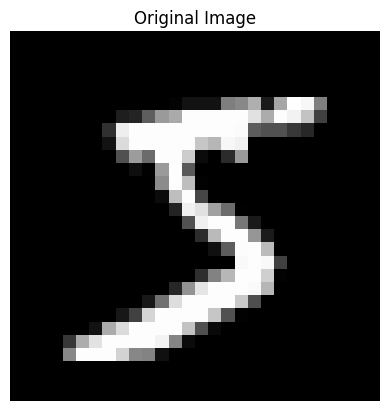

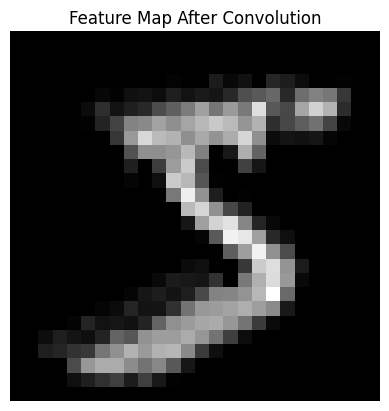

In [10]:
# Show original image
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

# Show feature map produced by convolution layer
plt.imshow(feature_map[0, :, :, 0], cmap="gray")
plt.title("Feature Map After Convolution")
plt.axis("off")
plt.show()



---

# 🧠 What will observe


* first image = handwritten digit
* second image = transformed version after convolution

That second image highlights some patterns more strongly.

This is beautiful because we can literally see:

```text
CNN is not guessing magic
CNN is extracting patterns
```

# 🧪 Step 10 — Use more filters


In [11]:
# Create another model with 4 filters
model_multi = models.Sequential()

# Add convolution layer with 4 filters
# This means the model will learn 4 different small pattern detectors
model_multi.add(layers.Conv2D(4, (3, 3), activation="relu", input_shape=(28, 28, 1)))

# 🧪 Step 11 — Generate multiple feature maps


In [12]:

# Pass the same image through the model
multi_feature_maps = model_multi.predict(sample_image)

# Print shape of output
print("Multi feature map shape:", multi_feature_maps.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Multi feature map shape: (1, 26, 26, 4)


```

Possible output:

```text
Multi feature map shape: (1, 26, 26, 4)
```

Meaning:

* 1 image
* output size 26×26
* 4 different feature maps

Because we used **4 filters**.

# 🧪 Step 12 — Plot all feature maps


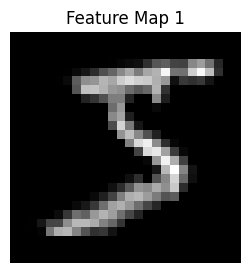

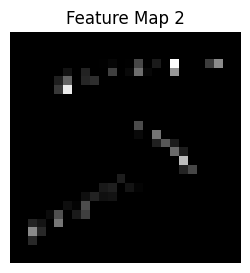

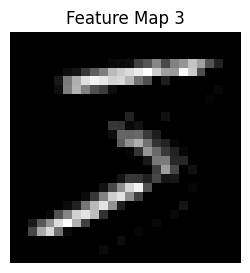

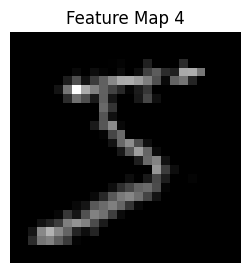

In [13]:
# Display all 4 feature maps
for i in range(4):
    plt.figure(figsize=(3, 3))
    
    # Show one feature map at a time
    plt.imshow(multi_feature_maps[0, :, :, i], cmap="gray")
    
    # Add title so students know which filter output they are seeing
    plt.title(f"Feature Map {i+1}")
    
    # Remove axis for cleaner display
    plt.axis("off")
    
    # Show the image
    plt.show()




---

# 🧠 What We should understand here

Each feature map looks a little different because each filter is learning a different pattern.

So this is the core idea:

```text
One image
→ many filters
→ many feature maps
→ many learned patterns
```

---

# 🤖 Milo’s super simple summary

```text
Convolution layer scans small parts of an image
using filters.
Each filter looks for a specific pattern.
The output is called a feature map.
```

---

# 📌 One very important note

At the beginning of training, filters are **random**.

That means CNN does not already know edges, curves, or corners.

It learns them during training.

So at first the feature maps may look weird.

After training, filters become smarter.

That is how CNN learns.

---



# 🧪  practice


### Practice 1

Change number of filters from `4` to `8`

```python
model_multi.add(layers.Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1)))
```

Ask them:

```text
How many feature maps do you get now?
```

---

### Practice 2

Change filter size from `(3,3)` to `(5,5)`

```python
model_multi.add(layers.Conv2D(4, (5, 5), activation="relu", input_shape=(28, 28, 1)))
```

Ask them:

```text
Did the output size change?
```

---

### Practice 3

Try different digit images

```python
sample_image = x_train[10:11]
```

Ask them:

```text
Do the feature maps change for different digits?
```

---

